In [3]:
import pandas as pd

df=pd.read_csv('heart.csv',na_values='?')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [5]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [6]:
df.nunique()

Age                         41
Sex                          2
Chest pain type              4
BP                          47
Cholesterol                144
FBS over 120                 2
EKG results                  3
Max HR                      90
Exercise angina              2
ST depression               39
Slope of ST                  3
Number of vessels fluro      4
Thallium                     3
Heart Disease                2
dtype: int64

In [7]:
#Target
df['Heart Disease'].unique()

<StringArray>
['Presence', 'Absence']
Length: 2, dtype: str

In [8]:
df['ST depression'].unique()

array([2.4, 1.6, 0.3, 0.2, 0.4, 0.6, 1.2, 4. , 0.5, 0. , 2.6, 1.8, 3.1,
       1.4, 0.1, 2.5, 2.3, 3.4, 0.9, 1.9, 2.2, 0.8, 1. , 3.6, 1.1, 3. ,
       2. , 1.5, 4.2, 3.2, 0.7, 5.6, 3.8, 2.1, 2.9, 2.8, 3.5, 6.2, 1.3])

In [9]:
num_df=df.select_dtypes(include='number')
num_df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='str')

In [10]:
from scipy.stats import zscore
z_score=num_df.apply(zscore)

outliers=(z_score.abs()>3)
outliers.sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         2
Cholesterol                4
FBS over 120               0
EKG results                0
Max HR                     1
Exercise angina            0
ST depression              2
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64

In [11]:
#Display all the outliers
df[(outliers).any(axis=1)]

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,Presence
52,65,0,3,140,417,1,2,157,0,0.8,1,1,3,Absence
101,67,1,4,120,237,0,0,71,0,1.0,2,0,3,Presence
117,56,0,4,200,288,1,2,133,1,4.0,3,2,7,Presence
144,54,1,2,192,283,0,2,195,0,0.0,1,1,7,Presence
156,55,1,4,140,217,0,0,111,1,5.6,3,0,7,Presence
181,56,0,4,134,409,0,2,150,1,1.9,2,2,7,Presence
235,62,0,4,160,164,0,2,145,0,6.2,3,3,7,Presence


In [12]:
#Remove all the outliers
df_clean=df[(outliers<=3).all(axis=1)]
df_clean

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


In [13]:
num_df=df.select_dtypes(include='number')
num_df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='str')

In [14]:
num_df.nunique()

Age                         41
Sex                          2
Chest pain type              4
BP                          47
Cholesterol                144
FBS over 120                 2
EKG results                  3
Max HR                      90
Exercise angina              2
ST depression               39
Slope of ST                  3
Number of vessels fluro      4
Thallium                     3
dtype: int64

In [15]:
new_df=df[['Age','BP','Cholesterol','Max HR','ST depression']]

In [16]:
Q1=new_df.quantile(0.25)
Q3=new_df.quantile(0.75)

IQR=Q3-Q1

Lower_Limit=Q1-1.5*IQR
Upper_Limit=Q3+1.5*IQR

In [17]:
Outliers=(new_df>Upper_Limit) | (new_df<Lower_Limit)

Outliers.sum()

Age              0
BP               9
Cholesterol      5
Max HR           1
ST depression    4
dtype: int64

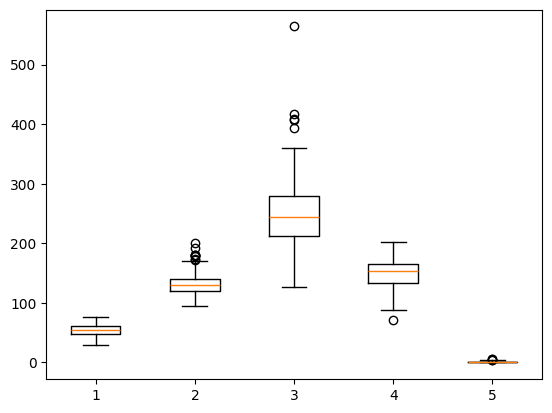

In [18]:
import matplotlib.pyplot as plt
plt.boxplot(new_df)
plt.show()

(array([[147., 123.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,  46., 213.,  11.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   9.,  78., 116.,  57.,   6.,   3.,   0.,   1.],
        [  0.,  22., 191.,  57.,   0.,   0.,   0.,   0.,   0.,   0.],
        [270.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]]),
 array([  0. ,  56.4, 112.8, 169.2, 225.6, 282. , 338.4, 394.8, 451.2,
        507.6, 564. ]),
 <a list of 5 BarContainer objects>)

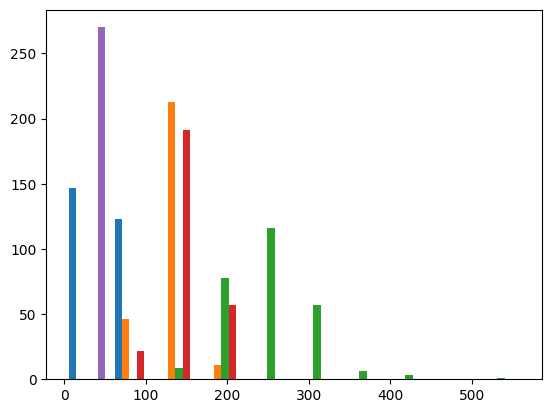

In [19]:
plt.hist(new_df)

<Axes: ylabel='Density'>

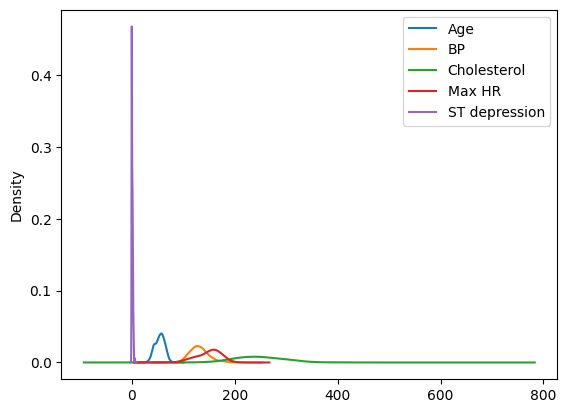

In [20]:
new_df.plot(kind='kde')

In [21]:
new_df[(outliers).any(axis=1)]

,Age,BP,Cholesterol,Max HR,ST depression
1,67,115,564,160,1.6
9,63,150,407,154,4.0
52,65,140,417,157,0.8
101,67,120,237,71,1.0
117,56,200,288,133,4.0
144,54,192,283,195,0.0
156,55,140,217,111,5.6
181,56,134,409,150,1.9
235,62,160,164,145,6.2


In [22]:
new_df.nunique()

Age               41
BP                47
Cholesterol      144
Max HR            90
ST depression     39
dtype: int64

In [23]:
new_df.head()

,Age,BP,Cholesterol,Max HR,ST depression
0,70,130,322,109,2.4
1,67,115,564,160,1.6
2,57,124,261,141,0.3
3,64,128,263,105,0.2
4,74,120,269,121,0.2


In [24]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()

new_df_scaled=scaler.fit_transform(new_df)

In [25]:
new_df_scaled=pd.DataFrame(new_df_scaled,columns=new_df.columns)
new_df_scaled.round(2)

,Age,BP,Cholesterol,Max HR,ST depression
0,1.15,0.00,1.15,-1.35,1.00
1,0.92,-0.75,4.76,0.20,0.50
2,0.15,-0.30,0.24,-0.38,-0.31
3,0.69,-0.10,0.27,-1.47,-0.38
4,1.46,-0.50,0.36,-0.98,-0.38
...,...,...,...,...,...
265,-0.23,2.10,-0.69,0.26,-0.19
266,-0.85,-0.50,0.27,0.59,-0.50
267,0.08,0.50,0.73,-0.02,0.31
268,0.15,0.50,-0.79,-0.17,-0.25


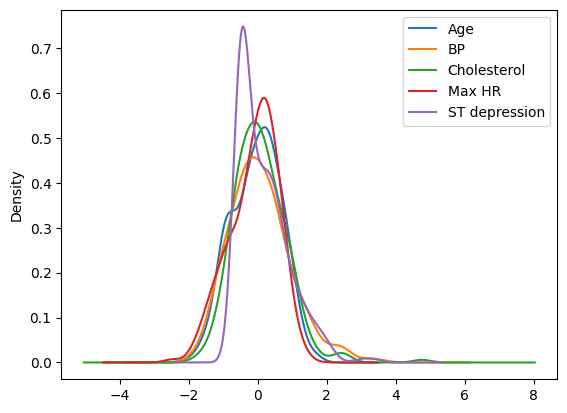

In [26]:
import matplotlib.pyplot as plt
new_df_scaled.plot(kind='kde')
plt.show()

In [27]:
import pandas as pd
df=pd.read_csv('heart.csv')

In [28]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [29]:
df.nunique()

Age                         41
Sex                          2
Chest pain type              4
BP                          47
Cholesterol                144
FBS over 120                 2
EKG results                  3
Max HR                      90
Exercise angina              2
ST depression               39
Slope of ST                  3
Number of vessels fluro      4
Thallium                     3
Heart Disease                2
dtype: int64

In [30]:
df['Number of vessels fluro'].unique()

array([3, 0, 1, 2])

In [31]:
df['EKG results'].unique()

array([2, 0, 1])

In [32]:
df['Chest pain type'].unique()

array([4, 3, 2, 1])

In [33]:
df['FBS over 120'].unique()

array([0, 1])

In [34]:
df['Heart Disease'].unique()

<StringArray>
['Presence', 'Absence']
Length: 2, dtype: str

In [35]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['Heart Disease']=le.fit_transform(df['Heart Disease'])

In [36]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [37]:
corr_matrix=new_df.corr()

In [38]:
corr_matrix

,Age,BP,Cholesterol,Max HR,ST depression
Age,1.000000,0.273053,0.220056,-0.402215,0.194234
BP,0.273053,1.000000,0.173019,-0.039136,0.222800
Cholesterol,0.220056,0.173019,1.000000,-0.018739,0.027709
Max HR,-0.402215,-0.039136,-0.018739,1.000000,-0.349045
ST depression,0.194234,0.222800,0.027709,-0.349045,1.000000


<Axes: >

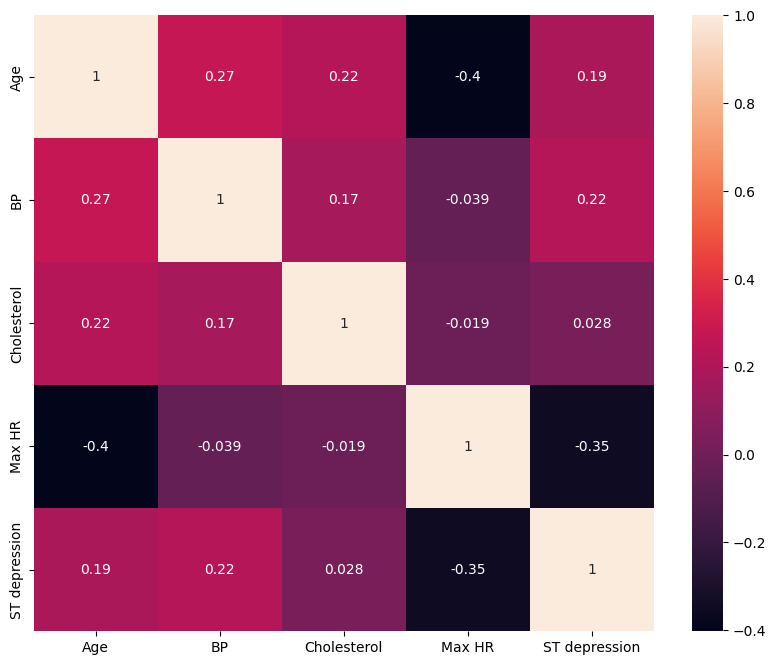

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix,annot=True)

In [40]:
new_df.var().round(2)

Age                82.98
BP                319.04
Cholesterol      2671.47
Max HR            536.65
ST depression       1.31
dtype: float64

In [41]:
from sklearn.feature_selection import VarianceThreshold
vt=VarianceThreshold()

new_data=vt.fit_transform(new_df)


In [42]:
vt.get_support()

array([ True,  True,  True,  True,  True])

In [43]:
import pandas as pd
df=pd.read_csv('heart.csv')

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [44]:
df['Heart Disease']=df['Heart Disease'].map({'Absence':0,
                                             'Presence':1})

In [45]:
num_df=df.select_dtypes(include='number')

In [46]:
num_df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='str')

In [47]:
x=num_df.drop('Heart Disease',axis=1)
y=num_df['Heart Disease']

In [48]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
rfe=RFE(estimator=model,n_features_to_select=5)


In [49]:
rfe.fit(x,y)

c:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",5
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [50]:
selected_features=x.columns[rfe.support_]
selected_features

Index(['Sex', 'Chest pain type', 'Exercise angina', 'ST depression',
       'Number of vessels fluro'],
      dtype='str')

In [51]:
removed_features=x.columns[~rfe.support_]
removed_features

Index(['Age', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR',
       'Slope of ST', 'Thallium'],
      dtype='str')

In [52]:
ranking=pd.DataFrame({"Features":x.columns,
                      "Ranking":rfe.ranking_})

In [53]:
ranking.sort_values('Ranking')

,Features,Ranking
1,Sex,1
2,Chest pain type,1
9,ST depression,1
8,Exercise angina,1
11,Number of vessels fluro,1
10,Slope of ST,2
5,FBS over 120,3
12,Thallium,4
6,EKG results,5
3,BP,6


In [54]:
import pandas as pd

df=pd.read_csv('heart.csv')

df['Heart Disease']=df['Heart Disease'].map({"Absence":0,
                                                "Presence":1})

In [55]:
num_df=df.select_dtypes(include='number')

In [56]:
num_df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='str')

In [57]:
x=num_df.drop('Heart Disease',axis=1)
y=num_df['Heart Disease']

In [58]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000)
sfs=SequentialFeatureSelector(estimator=model,n_features_to_select=5,direction='backward')

In [59]:
sfs.fit(x,y)

c:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    htt

,estimator estimator: estimator instanceAn unfitted estimator.,LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",5
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'backward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mi

In [60]:
selected_features=x.columns[sfs.support_]
selected_features

Index(['Max HR', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro',
       'Thallium'],
      dtype='str')

In [61]:
removed_features=x.columns[~sfs.support_]
removed_features

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'ST depression'],
      dtype='str')

In [62]:
new_data=pd.DataFrame({"Features":x.columns,
                        "Selected":sfs.support_})
new_data.sort_values('Selected',ascending=False)

,Features,Selected
7,Max HR,True
8,Exercise angina,True
10,Slope of ST,True
11,Number of vessels fluro,True
12,Thallium,True
0,Age,False
1,Sex,False
2,Chest pain type,False
3,BP,False
4,Cholesterol,False


In [63]:
x=num_df.drop('Heart Disease',axis=1)
y=num_df['Heart Disease']

In [64]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [65]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.01)
lasso.fit(x_scaled,y)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [66]:
coef=pd.DataFrame({"Features":x.columns,
                   "Coefficients":lasso.coef_})

In [67]:
coef.sort_values('Coefficients',ascending=False).round(2)

,Features,Coefficients
11,Number of vessels fluro,0.12
12,Thallium,0.12
2,Chest pain type,0.09
1,Sex,0.06
8,Exercise angina,0.05
9,ST depression,0.05
6,EKG results,0.03
3,BP,0.02
10,Slope of ST,0.02
4,Cholesterol,0.02


In [68]:
selected_features=coef[coef['Coefficients']!=0]['Features']
selected_features

1                         Sex
2             Chest pain type
3                          BP
4                 Cholesterol
5                FBS over 120
6                 EKG results
7                      Max HR
8             Exercise angina
9               ST depression
10                Slope of ST
11    Number of vessels fluro
12                   Thallium
Name: Features, dtype: str

In [69]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1)

ridge.fit(x_scaled,y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [70]:
coef=pd.DataFrame({"Features":x.columns,
"Coefficients":ridge.coef_})

In [71]:
coef.sort_values('Coefficients',ascending=False).round(2)

,Features,Coefficients
11,Number of vessels fluro,0.13
12,Thallium,0.11
2,Chest pain type,0.09
1,Sex,0.07
8,Exercise angina,0.05
9,ST depression,0.05
6,EKG results,0.04
3,BP,0.04
4,Cholesterol,0.03
10,Slope of ST,0.03


In [72]:
import pandas as pd
df=pd.read_csv('Loan.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [73]:
df.shape

(614, 13)

In [74]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [75]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [76]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [78]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [79]:
df.isnull().mean()*100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [80]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])


In [81]:
df['Married'].unique()

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [82]:
df['Married']=df['Married'].fillna(df['Married'].mode()[0])

In [83]:
df['Dependents'].unique()

<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

In [84]:
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])

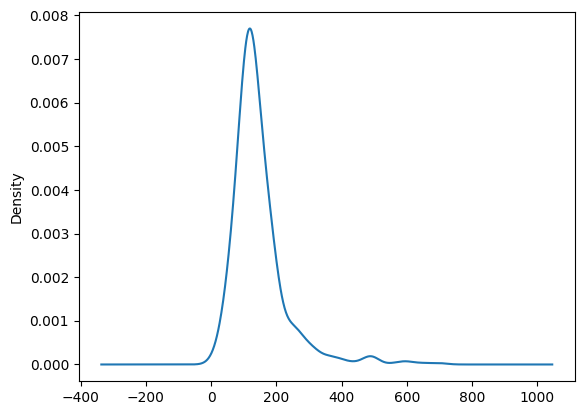

In [85]:
import matplotlib.pyplot as plt
df['LoanAmount'].plot(kind='kde')
plt.show()

In [86]:
df['LoanAmount']=df["LoanAmount"].fillna(df['LoanAmount'].median())
df['LoanAmount'].isnull().sum()

np.int64(0)

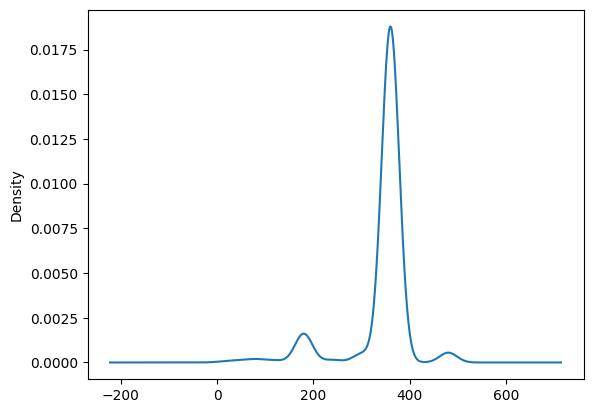

In [87]:
import matplotlib.pyplot as plt
df["Loan_Amount_Term"].plot(kind='kde')
plt.show()

In [88]:
df['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [89]:
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

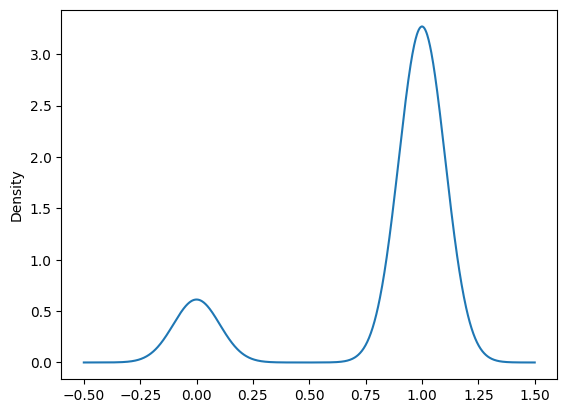

In [90]:
df['Credit_History'].plot(kind='kde')
plt.show()

In [91]:
df['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [92]:
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['Credit_History'].isnull().sum()

np.int64(0)

In [93]:
df['Self_Employed'].unique()
df['Self_Employed'].value_counts()

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

In [94]:
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [95]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [96]:
import pandas as pd
df=pd.read_csv('Loan.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [97]:
df.shape

(614, 13)

In [98]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [99]:
num_cols=df.select_dtypes(include='number').columns
num_cols

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')

In [100]:
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=5)

df[num_cols]=imputer.fit_transform(df[num_cols])

In [101]:
df[num_cols]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849.0,0.0,147.8,360.0,1.0
1,4583.0,1508.0,128.0,360.0,1.0
2,3000.0,0.0,66.0,360.0,1.0
3,2583.0,2358.0,120.0,360.0,1.0
4,6000.0,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900.0,0.0,71.0,360.0,1.0
610,4106.0,0.0,40.0,180.0,1.0
611,8072.0,240.0,253.0,360.0,1.0
612,7583.0,0.0,187.0,360.0,1.0


In [102]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [103]:
import pandas as pd

df=pd.read_csv('Loan.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [104]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [105]:
num_cols=df.select_dtypes(include='number').columns
num_cols

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')

In [106]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer=IterativeImputer()

df[num_cols]=imputer.fit_transform(df[num_cols])

In [107]:
df[num_cols].isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
dtype: int64

In [108]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [109]:
df.isnull().mean()*100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [110]:
df['Gender'].unique()

<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

In [111]:
df['Gender'].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [112]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])

In [113]:
df['Married'].unique()

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [114]:
df['Married'].value_counts(dropna=False)

Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

In [115]:
df['Married']=df['Married'].fillna(df['Married'].mode()[0])

In [116]:
df['Dependents'].unique()

<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

In [117]:
df['Dependents'].value_counts(dropna=False)

Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

In [118]:
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])

In [119]:
df['Self_Employed'].unique()

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [120]:
df["Self_Employed"]=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [121]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [122]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           225
Loan_Amount_Term      24
Credit_History        52
Property_Area          3
Loan_Status            2
dtype: int64

In [123]:
num_cont=df[['ApplicantIncome','CoapplicantIncome','LoanAmount']]

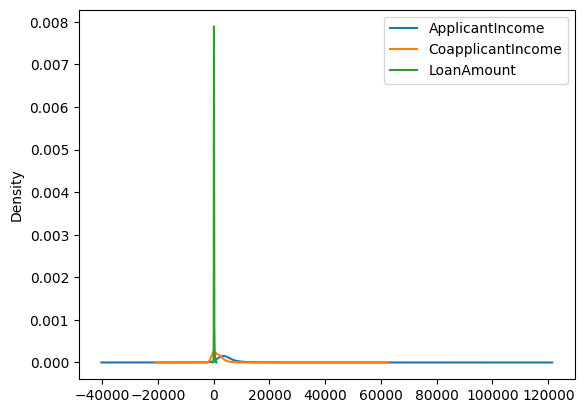

In [124]:
import matplotlib.pyplot as plt
num_cont.plot(kind='kde')
plt.show()

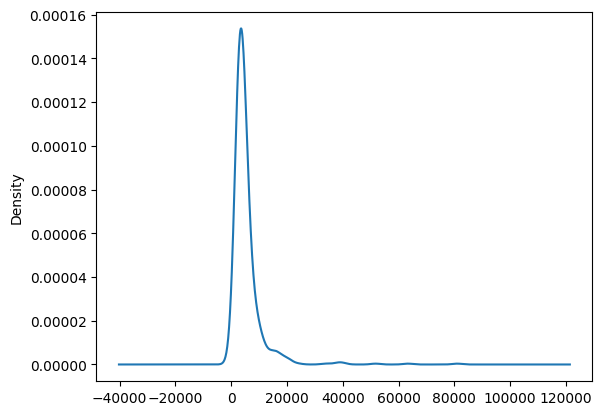

In [152]:
import matplotlib.pyplot as plt

df['ApplicantIncome'].plot(kind='kde')
plt.show()



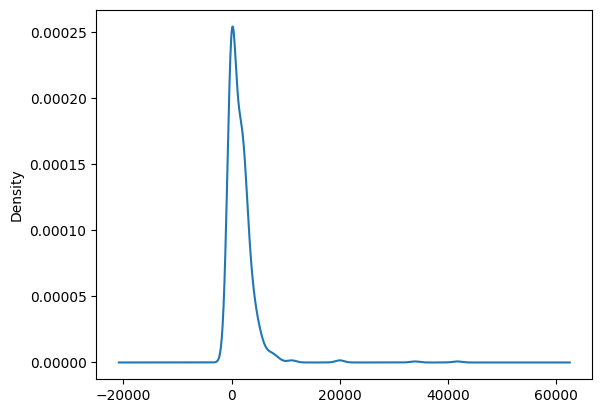

In [153]:
df['CoapplicantIncome'].plot(kind='kde')
plt.show()

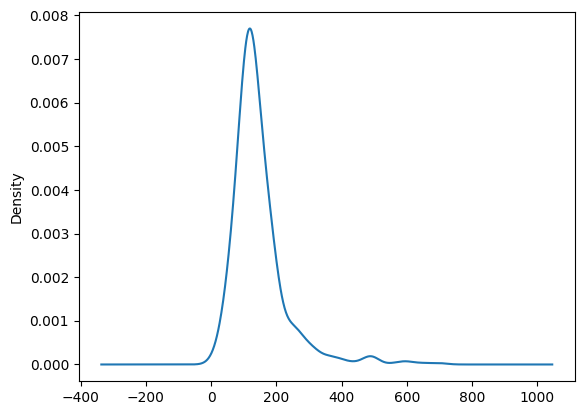

In [154]:

df['LoanAmount'].plot(kind='kde')
plt.show()

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

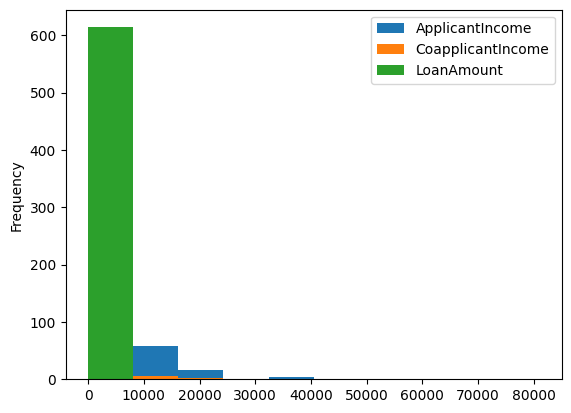

In [126]:
import matplotlib.pyplot as plt
num_cont.plot(kind='hist')
plt.plot

In [127]:
Q1=num_cont.quantile(0.25)
Q3=num_cont.quantile(0.75)

IQR=Q3-Q1
Lower_Limit=Q1-1.5*IQR
Upper_Limit=Q3+1.5*IQR


In [128]:
Outliers=(num_cont<Lower_Limit)|(num_cont>Upper_Limit)
Outliers.sum()


ApplicantIncome      50
CoapplicantIncome    18
LoanAmount           41
dtype: int64

In [130]:
df[(Outliers).any(axis=1)]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
5,LP001011,Male,Yes,2,Graduate,Yes,5417.0,4196.0,267.0,360.0,1.000000,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841.0,10968.0,349.0,360.0,1.000000,Semiurban,N
12,LP001028,Male,Yes,2,Graduate,No,3073.0,8106.0,200.0,360.0,1.000000,Urban,Y
21,LP001046,Male,Yes,1,Graduate,No,5955.0,5625.0,315.0,360.0,1.000000,Urban,Y
34,LP001100,Male,No,3+,Graduate,No,12500.0,3000.0,320.0,360.0,1.000000,Rural,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,LP002893,Male,No,0,Graduate,No,1836.0,33837.0,90.0,360.0,1.000000,Urban,N
592,LP002933,Male,No,3+,Graduate,Yes,9357.0,0.0,292.0,360.0,1.000000,Semiurban,Y
594,LP002938,Male,Yes,0,Graduate,Yes,16120.0,0.0,260.0,360.0,1.000000,Urban,Y
600,LP002949,Female,No,3+,Graduate,No,416.0,41667.0,350.0,180.0,0.821521,Urban,N


In [131]:
num_cont

,ApplicantIncome,CoapplicantIncome,LoanAmount
0,5849.0,0.0,138.159239
1,4583.0,1508.0,128.000000
2,3000.0,0.0,66.000000
3,2583.0,2358.0,120.000000
4,6000.0,0.0,141.000000
...,...,...,...
609,2900.0,0.0,71.000000
610,4106.0,0.0,40.000000
611,8072.0,240.0,253.000000
612,7583.0,0.0,187.000000


In [132]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
new_df=scaler.fit_transform(num_cont)

new_df=pd.DataFrame(new_df,columns=num_cont.columns)

In [133]:
new_df

,ApplicantIncome,CoapplicantIncome,LoanAmount
0,0.698029,-0.517358,0.155103
1,0.264096,0.139079,0.000000
2,-0.278492,-0.517358,-0.946565
3,-0.421422,0.509087,-0.122137
4,0.749786,-0.517358,0.198473
...,...,...,...
609,-0.312768,-0.517358,-0.870229
610,0.100600,-0.517358,-1.343511
611,1.459983,-0.412885,1.908397
612,1.292374,-0.517358,0.900763


In [141]:
import pandas as pd
df=pd.read_csv('Loan.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [142]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [143]:
Q1=num_cont.quantile(0.25)
Q3=num_cont.quantile(0.75)

IQR=Q3-Q1
Lower_Limit=Q1-1.5*IQR
Upper_Limit=Q3+1.5*IQR


In [144]:
Outliers=(num_cont<Lower_Limit)|(num_cont>Upper_Limit)
Outliers.sum()

ApplicantIncome      50
CoapplicantIncome    18
LoanAmount           41
dtype: int64

In [147]:
import numpy as np
num_cont['ApplicantIncome']=np.log1p(num_cont['ApplicantIncome'])
num_cont['CoapplicantIncome']=np.log1p(num_cont['CoapplicantIncome'])
num_cont['LoanAmount']=np.log1p(num_cont['LoanAmount'])

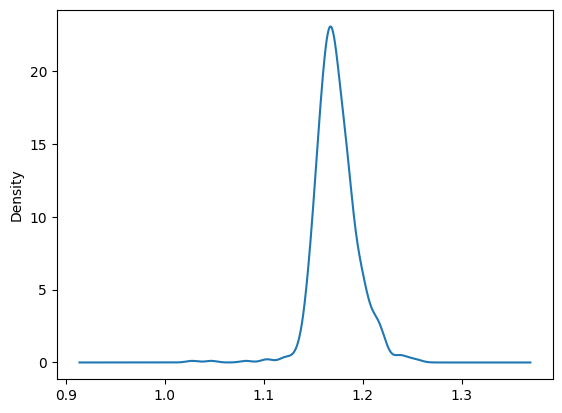

In [148]:
import matplotlib.pyplot as plt
num_cont['ApplicantIncome'].plot(kind='kde')
plt.show()

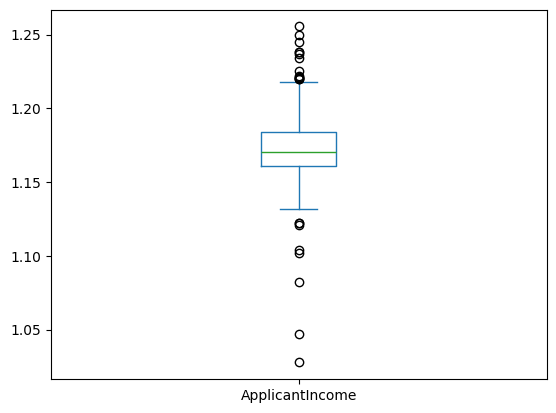

In [161]:
num_cont[['ApplicantIncome']].plot(kind='box')
plt.show()

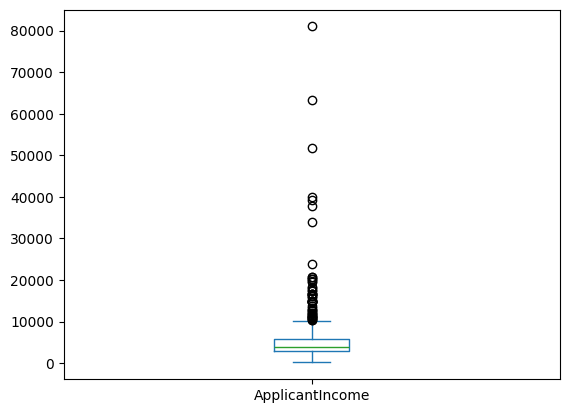

In [162]:
df[['ApplicantIncome']].plot(kind='box')
plt.show()

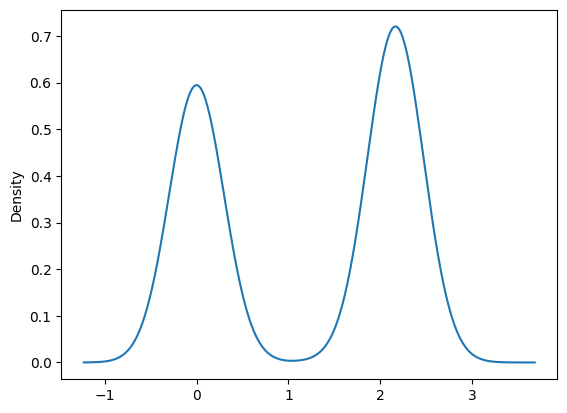

In [155]:
num_cont['CoapplicantIncome'].plot(kind='kde')
plt.show()

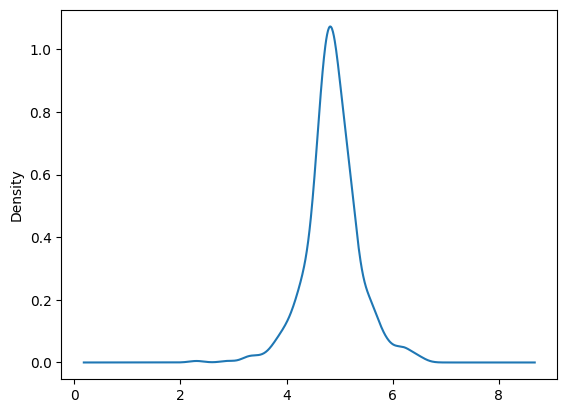

In [158]:
num_cont['LoanAmount'].plot(kind='kde')
plt.show()

In [163]:
import pandas as pd
df=pd.read_csv('Loan.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [166]:
num_df=df.select_dtypes(include='number').columns
num_df

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')

In [167]:
new_df=df[['ApplicantIncome','CoapplicantIncome','LoanAmount']]
new_df

,ApplicantIncome,CoapplicantIncome,LoanAmount
0,5849,0.0,NaN
1,4583,1508.0,128.0
2,3000,0.0,66.0
3,2583,2358.0,120.0
4,6000,0.0,141.0
...,...,...,...
609,2900,0.0,71.0
610,4106,0.0,40.0
611,8072,240.0,253.0
612,7583,0.0,187.0


In [168]:
new_df.isnull().sum()

ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
dtype: int64

In [169]:
new_df['LoanAmount'].value_counts(dropna=False)

LoanAmount
NaN      22
120.0    20
110.0    17
100.0    15
187.0    12
         ..
292.0     1
142.0     1
350.0     1
496.0     1
253.0     1
Name: count, Length: 204, dtype: int64

In [170]:
new_df['LoanAmount']=new_df['LoanAmount'].fillna(new_df['LoanAmount'].mode()[0])

In [171]:
new_df.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
dtype: int64

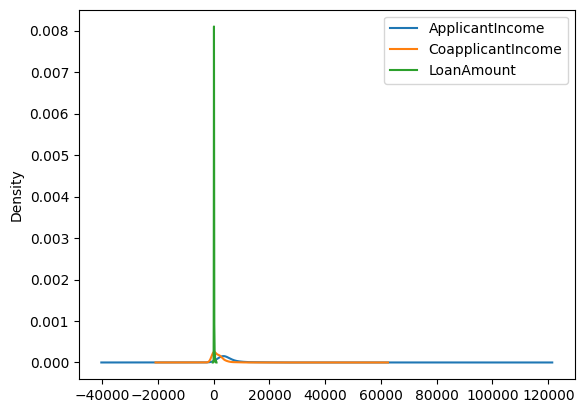

In [172]:
import matplotlib.pyplot as plt
new_df.plot(kind='kde')
plt.show()

In [173]:
Q1=new_df.quantile(0.25)
Q3=new_df.quantile(0.75)

IQR=Q3-Q1

Lower_Limit=Q1-1.5*IQR
Upper_Limit=Q3+1.5*IQR

In [174]:
Outliers=(new_df<Lower_Limit)|(new_df>Upper_Limit)

new_df[Outliers.any(axis=1)]

,ApplicantIncome,CoapplicantIncome,LoanAmount
5,5417,4196.0,267.0
9,12841,10968.0,349.0
12,3073,8106.0,200.0
21,5955,5625.0,315.0
34,12500,3000.0,320.0
...,...,...,...
581,1836,33837.0,90.0
592,9357,0.0,292.0
594,16120,0.0,260.0
600,416,41667.0,350.0


In [175]:
Outliers.sum()

ApplicantIncome      50
CoapplicantIncome    18
LoanAmount           41
dtype: int64

In [181]:
df_capped=new_df.copy()

In [187]:
import pandas as pd
df=pd.read_csv('Loan.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [190]:
df_encode=df.select_dtypes(include='str').columns
df_encode


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [195]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [196]:
df['Gender'].unique()

<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

In [197]:
df['Married'].unique()

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [198]:
df['Education'].unique()

<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

In [199]:
df['Self_Employed'].unique()

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [200]:
df['Credit_History'].unique()

array([ 1.,  0., nan])

In [201]:
df['Loan_Status'].unique()

<StringArray>
['Y', 'N']
Length: 2, dtype: str

In [202]:
new_labencode=df[['Gender','Married','Education','Self_Employed','Loan_Status']]

In [203]:
new_labencode

,Gender,Married,Education,Self_Employed,Loan_Status
0,Male,No,Graduate,No,Y
1,Male,Yes,Graduate,No,N
2,Male,Yes,Graduate,Yes,Y
3,Male,Yes,Not Graduate,No,Y
4,Male,No,Graduate,No,Y
...,...,...,...,...,...
609,Female,No,Graduate,No,Y
610,Male,Yes,Graduate,No,Y
611,Male,Yes,Graduate,No,Y
612,Male,Yes,Graduate,No,Y


In [206]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df_new_labencode=new_labencode.copy()

for col in new_labencode.columns:
    df_new_labencode[col]=le.fit_transform(df_new_labencode[col])

df_new_labencode

,Gender,Married,Education,Self_Employed,Loan_Status
0,1,0,0,0,1
1,1,1,0,0,0
2,1,1,0,1,1
3,1,1,1,0,1
4,1,0,0,0,1
...,...,...,...,...,...
609,0,0,0,0,1
610,1,1,0,0,1
611,1,1,0,0,1
612,1,1,0,0,1


In [207]:
df.nunique()


Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [208]:
df['Dependents'].unique()

<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

In [209]:
df['Property_Area'].unique()

<StringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str

In [210]:
df['Loan_Amount_Term'].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [211]:
new_ordencode=df[['Dependents']]

In [215]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()

df_new_ordencode=new_ordencode.copy()
for col in new_ordencode.columns:
    df_new_ordencode[[col]]=oe.fit_transform(df_new_ordencode[[col]])
df_new_ordencode

,Dependents
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0
...,...
609,0.0
610,3.0
611,1.0
612,2.0


,Property_Area
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...
...,...
609,<Compressed Sparse Row sparse matrix of dtype ...
610,<Compressed Sparse Row sparse matrix of dtype ...
611,<Compressed Sparse Row sparse matrix of dtype ...
612,<Compressed Sparse Row sparse matrix of dtype ...


In [220]:
from sklearn.preprocessing import OneHotEncoder
oh=OneHotEncoder(sparse_output=False)
encoded=oh.fit_transform(df[['Property_Area']])
encoded_df=pd.DataFrame(encoded,columns=oh.get_feature_names_out(['Property_Area']))

encoded_df

,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
609,1.0,0.0,0.0
610,1.0,0.0,0.0
611,0.0,0.0,1.0
612,0.0,0.0,1.0


In [222]:
num_df=df.select_dtypes(include='number')
num_df

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,NaN,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0
610,4106,0.0,40.0,180.0,1.0
611,8072,240.0,253.0,360.0,1.0
612,7583,0.0,187.0,360.0,1.0


In [228]:
num_df.isnull().sum()

ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
dtype: int64

In [233]:
num_df['CoapplicantIncome'].unique()

array([0.00000000e+00, 1.50800000e+03, 2.35800000e+03, 4.19600000e+03,
       1.51600000e+03, 2.50400000e+03, 1.52600000e+03, 1.09680000e+04,
       7.00000000e+02, 1.84000000e+03, 8.10600000e+03, 2.84000000e+03,
       1.08600000e+03, 3.50000000e+03, 5.62500000e+03, 1.91100000e+03,
       1.91700000e+03, 2.92500000e+03, 2.25300000e+03, 1.04000000e+03,
       2.08300000e+03, 3.36900000e+03, 1.66700000e+03, 3.00000000e+03,
       2.06700000e+03, 1.33000000e+03, 1.45900000e+03, 7.21000000e+03,
       1.66800000e+03, 1.21300000e+03, 2.33600000e+03, 3.44000000e+03,
       2.27500000e+03, 1.64400000e+03, 1.16700000e+03, 1.59100000e+03,
       2.20000000e+03, 2.25000000e+03, 2.85900000e+03, 3.79600000e+03,
       3.44900000e+03, 4.59500000e+03, 2.25400000e+03, 3.06600000e+03,
       1.87500000e+03, 1.77400000e+03, 4.75000000e+03, 3.02200000e+03,
       4.00000000e+03, 2.16600000e+03, 1.88100000e+03, 2.53100000e+03,
       2.00000000e+03, 2.11800000e+03, 4.16700000e+03, 2.90000000e+03,
      

In [238]:
num_df['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [231]:
num_df['LoanAmount']=num_df['LoanAmount'].fillna(num_df['LoanAmount'].mode()[0])

In [234]:
num_df['CoapplicantIncome']=num_df['CoapplicantIncome'].fillna(num_df['CoapplicantIncome'].mode()[0])

In [236]:
num_df['Credit_History']=num_df['Credit_History'].fillna(num_df['Credit_History'].mode()[0])

In [ ]:
num_df['Loan_Amount_Term']=num_df['Loan_Amount_Term'].fillna(num_df['Loan_Amount_Term'].mode()[0])

In [240]:
num_df.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
dtype: int64

In [241]:
corr_mat=num_df.corr()

<Axes: >

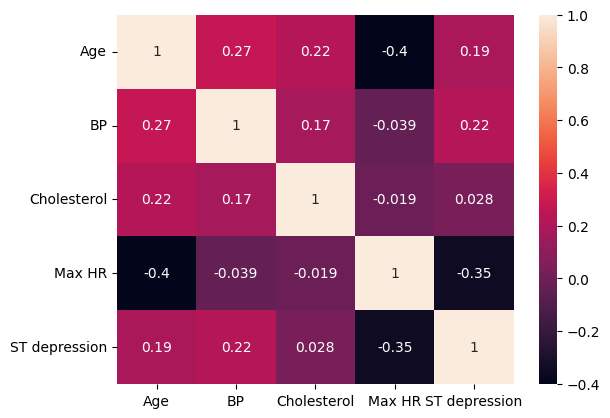

In [243]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix,annot=True)

In [247]:
var=num_df.var()
var

ApplicantIncome      3.732039e+07
CoapplicantIncome    8.562930e+06
LoanAmount           7.086435e+03
Loan_Amount_Term     4.151048e+03
Credit_History       1.241425e-01
dtype: float64

In [251]:
from sklearn.feature_selection import VarianceThreshold
vt=VarianceThreshold()

new_df=vt.fit_transform(num_df)
vt.get_support()

array([ True,  True,  True,  True,  True])

In [252]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [253]:
df['Loan_Status'].unique()

<StringArray>
['Y', 'N']
Length: 2, dtype: str

In [254]:
df['Loan_Status']=df['Loan_Status'].map({"Y":1,
"N":0})

In [255]:
num_df=df.select_dtypes(include='number')

In [256]:
num_df.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status'],
      dtype='str')

In [270]:
num_df.isnull().sum()


ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term      0
Credit_History        0
Loan_Status           0
dtype: int64

In [271]:
num_df['LoanAmount']=num_df['LoanAmount'].fillna(num_df['LoanAmount'].mode()[0])
num_df['Credit_History']=num_df['Credit_History'].fillna(num_df['Credit_History'].mode()[0])
num_df['CoapplicantIncome']=num_df['CoapplicantIncome'].fillna(num_df['CoapplicantIncome'].mode()[0])

In [272]:
x=num_df.drop('Loan_Status',axis=1)
y=num_df['Loan_Status']

In [276]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
rfe=RFE(estimator=model,n_features_to_select=4)
rfe.fit(x,y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",4
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [277]:
selected_features=x.columns[rfe.support_]
selected_features

Index(['CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
       'Credit_History'],
      dtype='str')

In [278]:
removed_features=x.columns[~rfe.support_]
removed_features

Index(['ApplicantIncome'], dtype='str')

In [279]:
new_data=pd.DataFrame({"Features":x.columns,
"Ranking":rfe.ranking_})

In [280]:
new_data

,Features,Ranking
0,ApplicantIncome,2
1,CoapplicantIncome,1
2,LoanAmount,1
3,Loan_Amount_Term,1
4,Credit_History,1


In [282]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector

model=LogisticRegression(max_iter=1000)
sfs=SequentialFeatureSelector(estimator=model,n_features_to_select=4)
sfs.fit(x,y)

,estimator estimator: estimator instanceAn unfitted estimator.,LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",4
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mix

In [283]:
selected_features=x.columns[sfs.support_]
selected_features


Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Credit_History'], dtype='str')

In [284]:
removed_features=x.columns[~sfs.support_]
removed_features

Index(['Loan_Amount_Term'], dtype='str')

In [286]:
new_data=pd.DataFrame({"Features":x.columns,
"Selected":sfs.support_})

In [287]:
new_data

,Features,Selected
0,ApplicantIncome,True
1,CoapplicantIncome,True
2,LoanAmount,True
3,Loan_Amount_Term,False
4,Credit_History,True


In [288]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scale_x=scaler.fit_transform(x)

In [300]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.1)
lasso.fit(scale_x,y)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [301]:
new_data=pd.DataFrame({"Features":x.columns,
                       "Coefficients":lasso.coef_})


In [309]:
new_data.round(2)

,Features,Coefficients
0,ApplicantIncome,0.01
1,CoapplicantIncome,-0.03
2,LoanAmount,-0.01
3,Loan_Amount_Term,-0.01
4,Credit_History,0.25


In [298]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scale_x=scaler.fit_transform(x)


In [303]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(scale_x,y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [304]:
new_data=pd.DataFrame({"Features":x.columns,
                       "Coefficients":ridge.coef_})

In [308]:
new_data.round(2)

,Features,Coefficients
0,ApplicantIncome,0.01
1,CoapplicantIncome,-0.03
2,LoanAmount,-0.01
3,Loan_Amount_Term,-0.01
4,Credit_History,0.25
